# Attention From Scratch

**Problem it solves:** older models read text one word at a time, so faraway words fade and nothing runs in parallel. Attention lets every token look at every other token in a single step.

**How it works:** each token makes a Query ("what am I looking for"), a Key ("what do I offer"), and a Value ("what I pass on"). Match every Query against every Key, turn those match scores into percentages with softmax, then mix the Values by those percentages.

**When to use it:** this is the engine inside every LLM you will ever call. You will not write it by hand at work — but the whole of [3_llm_inference.md](../3_llm_inference.md) (KV cache, GQA, context cost) only makes sense once you have written it once.

NumPy only. No PyTorch, no downloads. Read [1_attention_and_transformers.md](../1_attention_and_transformers.md) first.

## Step 1 — Softmax and one attention head

Four lines of math:

```
1. scores  = Q · Kᵀ           how well does each query match each key?
2. scaled  = scores / √d_k    keep the numbers in a sane range
3. weights = softmax(scaled)  turn scores into percentages that add up to 1
4. output  = weights · V      a blend of all values, weighted by match
```

`softmax` is written with the `- max` trick: `exp()` of a large number overflows, and subtracting the row maximum first changes nothing in the result but keeps every exponent small. Real libraries do exactly this.

In [1]:
import numpy as np

np.set_printoptions(precision=3, suppress=True)


def softmax(x, axis=-1):
    x_shifted = x - np.max(x, axis=axis, keepdims=True)  # overflow guard
    e = np.exp(x_shifted)
    return e / np.sum(e, axis=axis, keepdims=True)


def attention(Q, K, V, mask=None, scale=True):
    '''One attention head. Q,K,V are (n_tokens, d). Returns (output, weights).'''
    d_k = Q.shape[-1]
    scores = Q @ K.T                       # (n, n) - every token vs every token
    if scale:
        scores = scores / np.sqrt(d_k)     # step 2
    if mask is not None:
        scores = np.where(mask, scores, -np.inf)
    weights = softmax(scores, axis=-1)     # step 3
    return weights @ V, weights            # step 4


# 4 tokens, 8 numbers each
rng = np.random.default_rng(0)
X = rng.normal(size=(4, 8))
out, w = attention(X, X, X)

print("attention weights (each row adds up to 1):")
print(w)
print("\nrow sums:", w.sum(axis=1))
print("output shape:", out.shape, "- same shape in, same shape out")

attention weights (each row adds up to 1):
[[0.598 0.104 0.2   0.097]
 [0.015 0.892 0.039 0.054]
 [0.149 0.196 0.558 0.097]
 [0.08  0.304 0.108 0.508]]

row sums: [1. 1. 1. 1.]
output shape: (4, 8) - same shape in, same shape out


## Step 2 — Why divide by √d_k

Dot products grow with the size of the vector. With `d_k = 64`, two random vectors give scores spread roughly 8× wider than with `d_k = 1`.

Feed those big numbers into softmax and one weight becomes ~1.0 while the rest become ~0.0. The head stops *blending* and starts *picking one token*. Worse, softmax is flat out there, so the gradient nearly vanishes and the model learns almost nothing.

Watch the same scores with and without the scaling.

In [2]:
d_k = 64
Q = rng.normal(size=(5, d_k))
K = rng.normal(size=(5, d_k))

raw = Q @ K.T
scaled = raw / np.sqrt(d_k)

print(f"raw scores    : min {raw.min():7.2f}  max {raw.max():7.2f}")
print(f"scaled scores : min {scaled.min():7.2f}  max {scaled.max():7.2f}")

w_raw = softmax(raw)
w_scaled = softmax(scaled)

print("\nbiggest weight in each row:")
print("  without scaling:", w_raw.max(axis=1).round(3), " <- almost 1.0 = winner takes all")
print("  with scaling   :", w_scaled.max(axis=1).round(3), " <- still a real blend")

raw scores    : min   -9.87  max   17.20
scaled scores : min   -1.23  max    2.15

biggest weight in each row:
  without scaling: [0.744 0.949 1.    0.596 0.984]  <- almost 1.0 = winner takes all
  with scaling   : [0.432 0.356 0.562 0.291 0.393]  <- still a real blend


## Step 3 — The causal mask (don't read the future)

A chat model predicts the *next* token. In training it sees the whole sentence at once, so token 2 must not be allowed to look at token 3 — otherwise it learns to cheat, and then fails at real generation time when the future does not exist yet.

The fix: set every future score to `-inf` **before** the softmax, so `exp(-inf) = 0` and that weight becomes exactly zero.

In [3]:
def causal_mask(n):
    '''True = allowed to look. Lower triangle, including the diagonal.'''
    return np.tril(np.ones((n, n), dtype=bool))


sentence = ["the", "cat", "sat", "on"]
X = rng.normal(size=(len(sentence), 8))

_, w_open = attention(X, X, X)
_, w_causal = attention(X, X, X, mask=causal_mask(len(sentence)))

print("without mask - 'the' can see 'on', which is cheating:")
for word, row in zip(sentence, w_open):
    print(f"  {word:4s} {row}")

print("\nwith causal mask - every zero to the right is the future, blocked:")
for word, row in zip(sentence, w_causal):
    print(f"  {word:4s} {row}")

print("\nrow sums still 1.0:", w_causal.sum(axis=1))

without mask - 'the' can see 'on', which is cheating:
  the  [0.764 0.129 0.053 0.054]
  cat  [0.068 0.887 0.028 0.018]
  sat  [0.01  0.01  0.961 0.019]
  on   [0.008 0.005 0.014 0.973]

with causal mask - every zero to the right is the future, blocked:
  the  [1. 0. 0. 0.]
  cat  [0.071 0.929 0.    0.   ]
  sat  [0.01  0.01  0.979 0.   ]
  on   [0.008 0.005 0.014 0.973]

row sums still 1.0: [1. 1. 1. 1.]


## Step 4 — Seeing attention actually resolve a word

Here is the classic sentence: *"the trophy did not fit, it was too big"* — what does **it** point at?

In a real model the vectors and the projections are learned from trillions of tokens. Here we **hand-write** tiny 5-dimension vectors so the mechanism is visible: each dimension is a meaning slot, and `it` is written as a pronoun that also carries some "object" meaning.

The interesting part is `W_q`. A pronoun should not ask for *another pronoun* — it should ask for the **object** it stands for. So the hand-written query projection drops the pronoun slot when asking, while the keys keep it. That one choice is what makes `it` point at `trophy` instead of at itself.

That is exactly the job the learned `W_q` and `W_k` do inside a real model. Nothing here is trained — this is the *mechanism*, shrunk small enough to read.

In [4]:
# meaning slots:      object  negation  verb  function-word  pronoun
embeddings = {
    "the":    [0.0,    0.0,     0.0,   1.0,   0.0],
    "trophy": [1.0,    0.0,     0.0,   0.0,   0.0],
    "did":    [0.0,    0.0,     0.5,   0.5,   0.0],
    "not":    [0.0,    1.0,     0.0,   0.0,   0.0],
    "fit":    [0.0,    0.0,     1.0,   0.0,   0.0],
    "it":     [0.9,    0.0,     0.0,   0.0,   1.0],   # a pronoun standing for an object
}

words = list(embeddings)
E = np.array([embeddings[w] for w in words])
E = E / np.linalg.norm(E, axis=1, keepdims=True)   # length 1, so scores are pure direction

# hand-written query projection: when ASKING, ignore the pronoun slot (last one).
# Keys keep every slot. This is the job W_q and W_k learn in a real model.
W_q = np.diag([1.0, 1.0, 1.0, 1.0, 0.0])
SHARPNESS = 5.0   # real learned projections are bigger than 1.0, which sharpens softmax

Q = (E @ W_q) * SHARPNESS
_, w_sem = attention(Q, E, E, mask=causal_mask(len(words)))

row = words.index("it")
print("what 'it' looks at:")
for word, weight in sorted(zip(words, w_sem[row]), key=lambda p: -p[1]):
    bar = "#" * int(weight * 40)
    print(f"  {word:7s} {weight:.3f} {bar}")

what 'it' looks at:
  trophy  0.399 ###############
  it      0.243 #########
  the     0.089 ###
  did     0.089 ###
  not     0.089 ###
  fit     0.089 ###


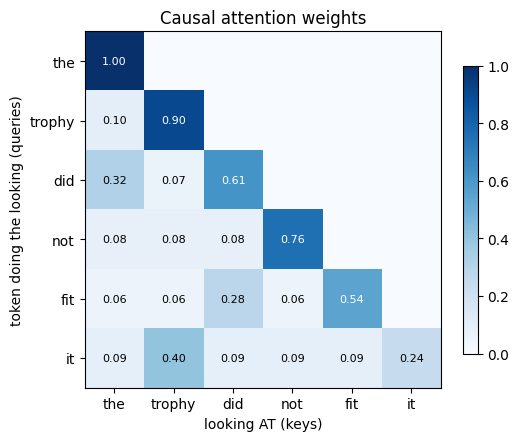

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(w_sem, cmap="Blues", vmin=0, vmax=1)

ax.set_xticks(range(len(words)), words)
ax.set_yticks(range(len(words)), words)
ax.set_xlabel("looking AT (keys)")
ax.set_ylabel("token doing the looking (queries)")
ax.set_title("Causal attention weights")

for i in range(len(words)):
    for j in range(len(words)):
        if w_sem[i, j] > 0.001:
            ax.text(j, i, f"{w_sem[i, j]:.2f}", ha="center", va="center",
                    fontsize=8, color="white" if w_sem[i, j] > 0.5 else "black")

fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## Step 5 — Multi-head attention

One head can only learn one kind of relationship. Language has many at the same time — grammar, who-did-what, topic, tone.

So instead of one head of size 512, use 8 heads of size 64. Same total compute, eight separate views. Each head gets its own `W_q`, `W_k`, `W_v`; the results are glued back together and passed through one more matrix `W_o`.

Nobody assigns the heads their jobs. They specialise on their own during training.

In [6]:
def multi_head_attention(X, W_q, W_k, W_v, W_o, n_heads, mask=None):
    n_tokens, d_model = X.shape
    d_head = d_model // n_heads

    Q, K, V = X @ W_q, X @ W_k, X @ W_v      # project once, then split

    heads, all_weights = [], []
    for h in range(n_heads):
        s = slice(h * d_head, (h + 1) * d_head)
        head_out, head_w = attention(Q[:, s], K[:, s], V[:, s], mask=mask)
        heads.append(head_out)
        all_weights.append(head_w)

    concat = np.concatenate(heads, axis=-1)   # glue the heads back together
    return concat @ W_o, np.array(all_weights)


d_model, n_heads, n_tokens = 64, 8, 6
X = rng.normal(size=(n_tokens, d_model))
W_q, W_k, W_v, W_o = (rng.normal(size=(d_model, d_model)) * 0.1 for _ in range(4))

out, head_weights = multi_head_attention(X, W_q, W_k, W_v, W_o, n_heads,
                                         mask=causal_mask(n_tokens))

print("input shape :", X.shape)
print("output shape:", out.shape, "- unchanged, so blocks can stack")
print("head weights:", head_weights.shape, "= (heads, tokens, tokens)")
print(f"\nlast token's attention, per head (all {n_heads} see the same input):")
for h in range(n_heads):
    print(f"  head {h}: {head_weights[h, -1].round(2)}")

input shape : (6, 64)
output shape: (6, 64) - unchanged, so blocks can stack
head weights: (8, 6, 6) = (heads, tokens, tokens)

last token's attention, per head (all 8 see the same input):
  head 0: [0.13 0.11 0.17 0.08 0.11 0.4 ]
  head 1: [0.32 0.14 0.16 0.09 0.17 0.11]
  head 2: [0.18 0.1  0.14 0.15 0.34 0.09]
  head 3: [0.35 0.09 0.23 0.15 0.1  0.08]
  head 4: [0.07 0.05 0.11 0.19 0.22 0.36]
  head 5: [0.24 0.15 0.15 0.13 0.18 0.14]
  head 6: [0.16 0.2  0.25 0.14 0.04 0.2 ]
  head 7: [0.14 0.1  0.19 0.17 0.18 0.22]


## Step 6 — MHA vs GQA vs MQA: the memory bill

Every head keeps its Keys and Values in the KV cache during generation. That cache is what makes long context expensive:

```
KV bytes per token = 2 × layers × kv_heads × head_dim × bytes_per_number
```

**GQA** (Grouped-Query Attention) keeps all the query heads but lets several of them **share** one Key/Value pair. Fewer KV heads, much smaller cache, almost the same quality. This is why Llama 3, Mistral and Qwen all use it — and why they chose GQA over MQA, which shares everything down to a single KV head and loses more quality.

Numbers below use a Llama-3-8B-shaped model: 32 layers, head_dim 128, 16-bit.

In [7]:
def kv_bytes_per_token(layers, kv_heads, head_dim, bytes_per_number=2):
    return 2 * layers * kv_heads * head_dim * bytes_per_number   # 2 = one K + one V


LAYERS, HEAD_DIM, QUERY_HEADS = 32, 128, 32
SEQ, USERS = 8_000, 32

print(f"{'scheme':6s} {'kv_heads':>9s} {'KB/token':>10s} {'GB @ 8k x 32 users':>22s}")
for name, kv_heads in [("MHA", 32), ("GQA", 8), ("MQA", 1)]:
    per_token = kv_bytes_per_token(LAYERS, kv_heads, HEAD_DIM)
    total_gb = per_token * SEQ * USERS / 1e9
    print(f"{name:6s} {kv_heads:9d} {per_token/1024:10.1f} {total_gb:22.1f}")

print(f"\nThe model weights themselves are about 16 GB in 16-bit.")
print("MHA's cache alone is far bigger than the model. GQA is what makes this servable.")

scheme  kv_heads   KB/token     GB @ 8k x 32 users
MHA           32      512.0                  134.2
GQA            8      128.0                   33.6
MQA            1       16.0                    4.2

The model weights themselves are about 16 GB in 16-bit.
MHA's cache alone is far bigger than the model. GQA is what makes this servable.


## Your turn — modify and debug on purpose

Guess the answer first, then run it.

1. In Step 2, change `d_k` from `64` to `4`. Does the unscaled version still collapse onto one token? What does that tell you about *why* the √d_k term exists?
2. In Step 3, flip the mask with `~causal_mask(4)`. Which words can each token see now, and why would a model trained this way be useless for generation?
3. In Step 4, change `"it"` to `[0.0, 0.0, 0.0, 0.0, 1.0]` — a pure pronoun with no object meaning left. Its query now becomes all zeros. What shape do the attention weights take, and what does that tell you about a query that "asks for nothing"?
4. Still in Step 4, set `SHARPNESS = 1.0`, then `20.0`. Does the *ranking* of words change, or only how confident it looks? Connect that back to temperature in [1_llm_setting.md](../../1_introduction/1_llm_setting.md).
5. In Step 5, set `n_heads = 1` with the same `d_model`. Compare the last token's attention row against the 8-head version — what information did you lose?
6. In Step 6, work out the cache for a 70B-shaped model (80 layers, 8 KV heads, head_dim 128) at 100k context, batch 32. Would it fit on one 80 GB H100? What are your three options if it does not?
7. Without AI help, write 3–5 sentences: *what problem does attention solve, how do Q/K/V produce an answer, and why does GQA exist?* If any part is fuzzy, that is the part to re-read.